# **RQ2**: Dynamic Community Detection

In [1]:
import os
import igraph as ig
import leidenalg

ModuleNotFoundError: No module named 'leidenalg'

In [2]:
import json

for i in range(1, 8):
    print(f'\nAnalyzing graph of snapshot {i}')
    file = os.path.join('networks_hybrid', f'graph_snap{i}_hybrid.igp')
    g = ig.Graph.Read_Pickle(file)
    
    partition = leidenalg.find_partition(
        g,
        leidenalg.RBConfigurationVertexPartition,
        weights='weight',
        resolution_parameter=1.0
    )
    print(f'\tCorrectly ran Leiden CD')
    
    print(f'\t#comms: {len(partition)}')

    communities = list()
    
    for j, com in enumerate(partition):
        print(f'\t\t{len(com)}')
        communities.append(list())
        for node in com:
            communities[j].append(g.vs[node]['token'])

    out = os.path.join('leiden_clusterings', f'clust_snap{i}.json')
    with open(out, 'w', encoding='utf-8') as f:
        json.dump(communities, f)


Analyzing graph of snapshot 1
	Correctly ran Leiden CD
	#comms: 34
		9420
		6310
		5061
		4150
		3772
		1977
		1885
		1667
		471
		5
		1
		1
		1
		1
		1
		1
		1
		1
		1
		1
		1
		1
		1
		1
		1
		1
		1
		1
		1
		1
		1
		1
		1
		1

Analyzing graph of snapshot 2
	Correctly ran Leiden CD
	#comms: 26
		7336
		4129
		3129
		2837
		2637
		2227
		1748
		1521
		1253
		1184
		1
		1
		1
		1
		1
		1
		1
		1
		1
		1
		1
		1
		1
		1
		1
		1

Analyzing graph of snapshot 3
	Correctly ran Leiden CD
	#comms: 39
		5057
		4264
		3443
		3248
		3164
		2616
		1231
		1225
		1071
		991
		961
		617
		114
		1
		1
		1
		1
		1
		1
		1
		1
		1
		1
		1
		1
		1
		1
		1
		1
		1
		1
		1
		1
		1
		1
		1
		1
		1
		1

Analyzing graph of snapshot 4
	Correctly ran Leiden CD
	#comms: 28
		6283
		5246
		4344
		4191
		3544
		3137
		2540
		2246
		1508
		1374
		1
		1
		1
		1
		1
		1
		1
		1
		1
		1
		1
		1
		1
		1
		1
		1
		1
		1

Analyzing graph of snapshot 5
	Correctly ran Leiden CD
	#comms: 34
		5430
		5360
		5359
		5095
		3

In [ ]:
import json

for i in range(1, 8):
    print(f'\nAnalyzing graph of snapshot {i}')
    file = os.path.join('networks_hybrid', f'graph_snap{i}_hybrid.igp')
    g = ig.Graph.Read_Pickle(file)
    
    partition = g.community_infomap(
        edge_weights='weight'
    )

    print(f'\tCorrectly ran Infomap CD')
    
    print(f'\t#comms: {len(partition)}')

    communities = list()
    
    for j, com in enumerate(partition):
        # print(f'\t\t{len(com)}')
        communities.append(list())
        for node in com:
            communities[j].append(g.vs[node]['token'])

    out = os.path.join('infomap_clusterings', f'clust_snap{i}.json')
    with open(out, 'w', encoding='utf-8') as f:
        json.dump(communities, f)


Analyzing graph of snapshot 1
	Correctly ran Infomap CD
	#comms: 87

Analyzing graph of snapshot 2
	Correctly ran Infomap CD
	#comms: 79

Analyzing graph of snapshot 3
	Correctly ran Infomap CD
	#comms: 114

Analyzing graph of snapshot 4
	Correctly ran Infomap CD
	#comms: 107

Analyzing graph of snapshot 5
	Correctly ran Infomap CD
	#comms: 79

Analyzing graph of snapshot 6
	Correctly ran Infomap CD
	#comms: 68

Analyzing graph of snapshot 7
	Correctly ran Infomap CD
	#comms: 76

Analyzing graph of snapshot 8
	Correctly ran Infomap CD
	#comms: 83

Analyzing graph of snapshot 9
	Correctly ran Infomap CD
	#comms: 64

Analyzing graph of snapshot 10
	Correctly ran Infomap CD
	#comms: 107


## Leiden communities comparison by snapshots

In [3]:
import json
import numpy as np
import os
import matplotlib.pyplot as plt
from matplotlib.path import Path
from matplotlib.patches import PathPatch
import numpy as np

In [4]:
def overlap_coeff(com1: list, com2: list) -> float:
    """
    Calculate Overlap Coefficient between two communities.
        
    ---
    
    Args:
        com1 (list): First community
        com2 (list): Second community
    
    Returns:
        float: Float representing the Overlap Coefficient
    """
    set1, set2 = set(com1), set(com2)
    return len(set1 & set2) / min(len(set1), len(set2))


def directional_overlap(com_prev: list, com_next: list) -> float:
    """
    Directional overlap from previous snapshot to next snapshot.
    Penalizes small → large, rewards large → small.
    """
    set_prev, set_next = set(com_prev), set(com_next)
    inter = len(set_prev & set_next)

    if inter == 0:
        return 0.0

    return inter / len(set_next)


def compare_partitions(part_prev: list, part_cur: str) -> list:
    """
    Compare two partitions (lists of communities) from consecutive snapshots by computing
    the Jaccard similarity between each pair of communities.

    Args:
        snap_prev (str): Path to the JSON file containing the previous snapshot's partition.
        snap_cur (str): Path to the JSON file containing the current snapshot's partition.

    Returns:
        list: A matrix (list of lists) where each element [i][j] is the Overlap Coefficient
              between the i-th community in the current snapshot and the j-th community in the previous snapshot.
    """
    sim_matrix = np.zeros((len(part_cur), len(part_prev)))
    for i, com_cur in enumerate(part_cur):
        for j, com_prev in enumerate(part_prev):
            sim = directional_overlap(com_prev, com_cur)
            sim_matrix[i][j] = sim
            
    return sim_matrix

In [11]:
from collections import defaultdict
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D


# --------------------------------------------------
# Graph construction
# --------------------------------------------------
def build_temporal_graph(sim_matrices, community_sizes, threshold):
    G = nx.DiGraph()

    for t, sim in enumerate(sim_matrices):
        n_curr, n_prev = sim.shape

        for i in range(n_prev):
            if community_sizes[t][i] > 10:
                G.add_node((t, i), snapshot=t, size=community_sizes[t][i])

        for j in range(n_curr):
            if community_sizes[t + 1][j] > 10:
                G.add_node((t + 1, j), snapshot=t + 1, size=community_sizes[t + 1][j])

        for i in range(n_prev):
            for j in range(n_curr):
                w = sim[j, i]
                if (
                    w >= threshold
                    and community_sizes[t][i] > 10
                    and community_sizes[t + 1][j] > 10
                ):
                    G.add_edge(
                        (t, i),
                        (t + 1, j),
                        weight=w,
                        label=f"{w:.2f}",
                    )

    return G


# --------------------------------------------------
# Layered layout
# --------------------------------------------------
def compute_layered_layout(G, x_spacing, y_spacing):
    pos = {}
    layers = {}

    for n in G.nodes():
        snapshot = G.nodes[n].get("snapshot", None)
        if snapshot is None:
            raise ValueError(f"Node {n} has no snapshot attribute")
        layers.setdefault(snapshot, []).append(n)

    for t in sorted(layers):
        for idx, n in enumerate(sorted(layers[t])):
            pos[n] = (t * x_spacing, -idx * y_spacing)

    return pos


# --------------------------------------------------
# Stats and node coloring
# --------------------------------------------------
def compute_stats_and_colors(G, community_sizes, last_snapshot):
    stats = defaultdict(
        lambda: {
            "total": -1,
            "total_over": 0,
            "internal": 0,
            "births": 0,
            "deaths": 0,
            "isolated": 0,
            "merges": 0,
            "splits": 0,
        }
    )

    node_colors = []

    for n in G.nodes():
        snap = n[0]

        if stats[snap]["total"] == -1:
            stats[snap]["total"] = len(community_sizes[snap])

        stats[snap]["total_over"] += 1

        indeg = G.in_degree(n)
        outdeg = G.out_degree(n)

        if outdeg > 1:
            stats[snap]['splits'] += 1

        if indeg > 1:
            stats[snap]['merges'] += 1

        # boundary snapshots
        if snap == 0 and outdeg > 0:
            node_colors.append("black")
            stats[snap]["internal"] += 1
            continue

        if snap == last_snapshot and indeg > 0:
            node_colors.append("black")
            stats[snap]["internal"] += 1
            continue

        if indeg == 0 and outdeg > 0:
            node_colors.append("green")
            stats[snap]["births"] += 1

        elif indeg > 0 and outdeg == 0:
            node_colors.append("red")
            stats[snap]["deaths"] += 1

        elif indeg == 0 and outdeg == 0:
            node_colors.append("purple")
            stats[snap]["isolated"] += 1

        else:
            node_colors.append("black")
            stats[snap]["internal"] += 1

    return stats, node_colors


def print_stats(stats):
    print("\nSnapshot | Total | Total>50 | Internal | Births | Deaths | Isolated | Merges | Splits")
    print("-" * 85)

    for snap in sorted(stats):
        s = stats[snap]
        print(
            f"{snap:8} | {s['total']:5} | {s['total_over']:8} | "
            f"{s['internal']:8} | {s['births']:6} | "
            f"{s['deaths']:6} | {s['isolated']:8} | "
            f"{s['merges']:6} | {s['splits']:6}"
        )


# --------------------------------------------------
# Drawing helpers
# --------------------------------------------------
def draw_nodes(G, pos, node_colors, node_size):
    nx.draw_networkx_nodes(
        G,
        pos,
        node_size=node_size,
        node_color=node_colors,
        alpha=0.8,
    )


def draw_node_labels(G, pos):
    node_labels = {n: str(G.nodes[n]["size"]) for n in G.nodes()}

    label_pos = {
        n: (pos[n][0], pos[n][1] + 0.3)
        for n in pos
    }

    nx.draw_networkx_labels(
        G,
        label_pos,
        labels=node_labels,
        font_size=8,
    )


def draw_edges(G, pos, ax):
    weights = [G[u][v]["weight"] for u, v in G.edges()]

    norm = mcolors.Normalize(vmin=min(weights), vmax=max(weights))
    cmap = cm.plasma

    nx.draw_networkx_edges(
        G,
        pos,
        edge_color=weights,
        edge_cmap=cmap,
        edge_vmin=norm.vmin,
        edge_vmax=norm.vmax,
        alpha=0.6,
    )

    sm = cm.ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])
    plt.colorbar(sm, ax=ax, label="Community directional overlap coefficient")


def draw_legend():
    legend_elements = [
        Line2D([0], [0], marker="o", color="w",
               label="Birth", markerfacecolor="green", markersize=10),
        Line2D([0], [0], marker="o", color="w",
               label="Death", markerfacecolor="red", markersize=10),
        Line2D([0], [0], marker="o", color="w",
               label="Isolated", markerfacecolor="purple", markersize=10),
    ]

    plt.legend(
        handles=legend_elements,
        loc="lower right",
        frameon=False,
    )


# --------------------------------------------------
# Main plotting function
# --------------------------------------------------
def plot_temporal_community_similarity(
    sim_matrices,
    community_sizes,
    threshold=0.5,
    x_spacing=3.0,
    y_spacing=1.0,
    node_size=50,
    clustering="Leiden",
):
    G = build_temporal_graph(sim_matrices, community_sizes, threshold)
    pos = compute_layered_layout(G, x_spacing, y_spacing)

    _, ax = plt.subplots(figsize=(14, 8))

    stats, node_colors = compute_stats_and_colors(
        G,
        community_sizes,
        last_snapshot=max(G.nodes())[0],
    )

    print_stats(stats)

    draw_nodes(G, pos, node_colors, node_size)
    draw_node_labels(G, pos)
    draw_edges(G, pos, ax)
    draw_legend()

    plt.title(
        f"Evolution of {clustering}-detected communities",
        fontsize=20,
    )

    plt.axis("off")
    plt.tight_layout()
    plt.show()


In [12]:
sim_matrices = list()
community_sizes = list()

for i in range(1, 8):
    file = os.path.join('leiden_clusterings', f'clust_snap{i}.json')
    if i > 1:
        part_prev = part_cur
    with open(file, 'r', encoding='utf-8') as f:
        part_cur = json.load(f)
    
    community_sizes.append(list())
    
    for com in part_cur:
        community_sizes[-1].append(len(com))
    
    if i == 1:
        continue
    
    matrix = compare_partitions(part_prev=part_prev, part_cur=part_cur)
    sim_matrices.append(matrix)


Snapshot | Total | Total>50 | Internal | Births | Deaths | Isolated | Merges | Splits
-------------------------------------------------------------------------------------
       0 |    34 |        9 |        7 |      0 |      0 |        2 |      0 |      1
       1 |    26 |       10 |        7 |      2 |      1 |        0 |      0 |      4
       2 |    39 |       13 |        7 |      0 |      6 |        0 |      0 |      1
       3 |    28 |       10 |        8 |      2 |      0 |        0 |      0 |      4
       4 |    34 |       14 |        9 |      0 |      5 |        0 |      0 |      0
       5 |    42 |       11 |        8 |      2 |      1 |        0 |      0 |      1
       6 |    45 |       11 |       11 |      0 |      0 |        0 |      0 |      0


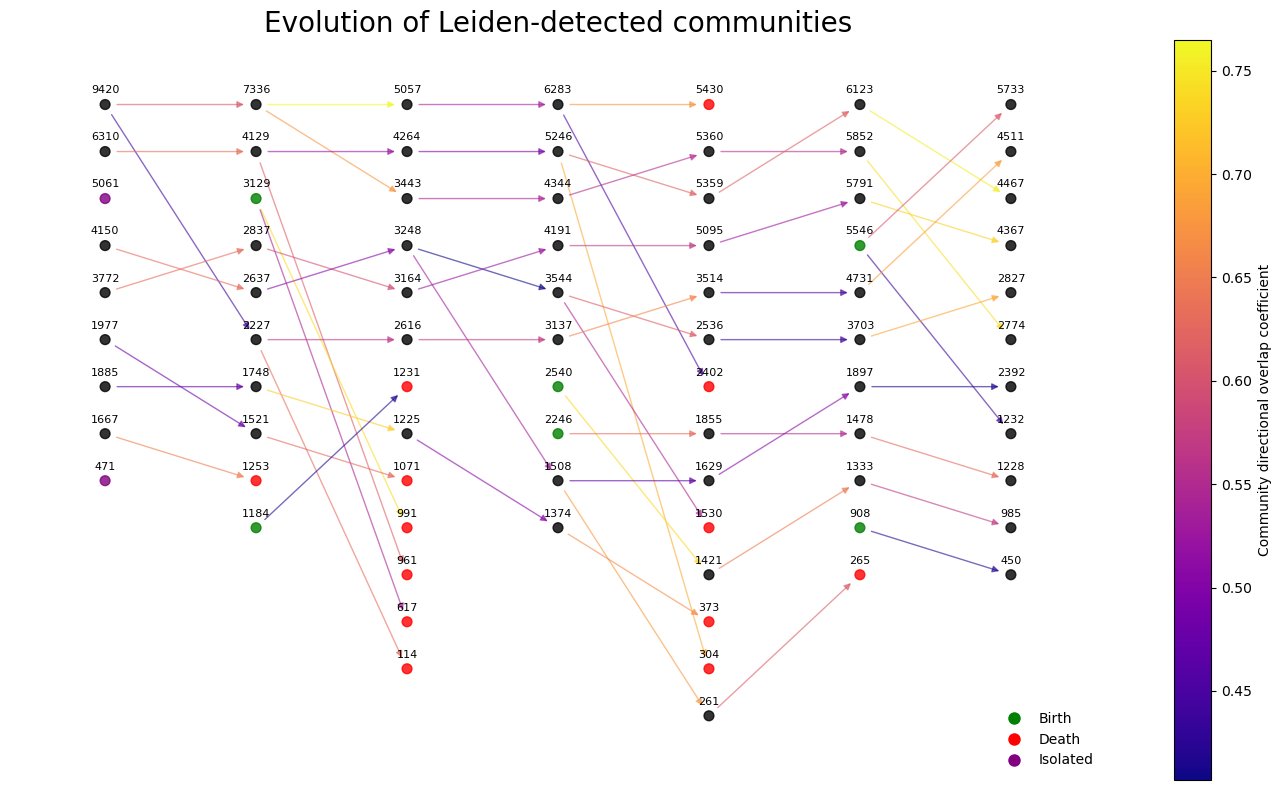

In [13]:
plot_temporal_community_similarity(sim_matrices, community_sizes, threshold=0.4)

#### Frequencies Entropy

In [14]:
import numpy as np

def community_freq_stats(freqs):
    freqs = np.asarray(freqs, dtype=float)

    n = len(freqs)

    if n == 0:
        return {
            "entropy_norm": 0.0,
            "n_eff": 0.0
        }

    if n == 1:
        return {
            "entropy_norm": 0.0,
            "n_eff": 1.0
        }

    p = freqs / freqs.sum()

    entropy = -np.sum(p * np.log(p))
    entropy_norm = entropy / np.log(n)
    n_eff = np.exp(entropy)

    return {
        "entropy_norm": entropy_norm,
        "n_eff": n_eff
    }

In [15]:
stats = []

for i in range(1, 8):
    print(f"Snapshot {i}")

    # load clustering
    file = os.path.join("leiden_clusterings", f"clust_snap{i}.json")
    with open(file, "r", encoding="utf-8") as f:
        part = json.load(f)

    # load graph
    file = os.path.join("networks_hybrid", f"graph_snap{i}_hybrid.igp")
    g = ig.Graph.Read_Pickle(file)

    # token -> frequency
    words_freqs = {v["token"]: v["freq"] for v in g.vs}

    snapshot_stats = []

    for com in part:
        freqs = [words_freqs[word] for word in com if word in words_freqs]
        s = community_freq_stats(freqs)

        if s is not None:
            snapshot_stats.append(s)

    stats.append(snapshot_stats)

Snapshot 1


/var/folders/68/gjrvx3m51494g9gp2r93j3vh0000gn/T/ipykernel_18625/1181363058.py:22: RuntimeWarning: divide by zero encountered in log
  entropy = -np.sum(p * np.log(p))
/var/folders/68/gjrvx3m51494g9gp2r93j3vh0000gn/T/ipykernel_18625/1181363058.py:22: RuntimeWarning: invalid value encountered in multiply
  entropy = -np.sum(p * np.log(p))


Snapshot 2
Snapshot 3
Snapshot 4
Snapshot 5
Snapshot 6
Snapshot 7


In [16]:
def print_table(stats):
    summary = []

    for snap_stats in stats:
        ent = np.array([c["entropy_norm"] for c in snap_stats])
        neff = np.array([c["n_eff"] for c in snap_stats])

        summary.append({
            "entropy_mean": ent.mean(),
            "entropy_median": np.median(ent),
            "neff_mean": neff.mean(),
            "neff_median": np.median(neff)
        })

    from tabulate import tabulate

    rows = []
    for i, row in enumerate(summary, start=1):
        rows.append([
            i,
            row["entropy_mean"],
            row["entropy_median"],
            row["neff_mean"],
            row["neff_median"]
        ])

    print(tabulate(
        rows,
        headers=["Snapshot", "Entropy (mean)", "Entropy (median)", "N_eff (mean)", "N_eff (median)"],
        floatfmt=".3f"
    ))

In [17]:
print_table(stats)

  Snapshot    Entropy (mean)    Entropy (median)    N_eff (mean)    N_eff (median)
----------  ----------------  ------------------  --------------  ----------------
         1           nan                 nan             nan               nan
         2             0.301               0.000         189.258             1.000
         3             0.262               0.000         144.901             1.000
         4             0.285               0.000         252.412             1.000
         5           nan                 nan             nan               nan
         6             0.205               0.000         159.546             1.000
         7             0.189               0.000         135.789             1.000


##### Demauro Entropy

In [18]:
import numpy as np
from collections import Counter

def demauro_entropy_stats(demauro_list):
    """
    Computes normalized entropy and effective number of categories (n_eff)
    for a list of Demauro coefficients (categorical labels).

    Parameters
    ----------
    demauro_list : list of int
        Categorical labels (e.g., 0,1,2 = basic, 3 = complex).

    Returns
    -------
    dict
        {
            "entropy_norm": float,  # normalized entropy (0-1)
            "n_eff": float          # effective number of categories
        }
    """
    # Count occurrences of each category
    freqs = np.array(list(Counter(demauro_list).values()), dtype=float)
    
    n = len(freqs)
    
    # Handle degenerate cases
    if n == 0:
        return {"entropy_norm": 0.0, "n_eff": 0.0}
    if n == 1:
        return {"entropy_norm": 0.0, "n_eff": 1.0}

    # Probabilities
    p = freqs / freqs.sum()
    
    # Shannon entropy
    entropy = -np.sum(p * np.log(p))
    
    # Normalized entropy
    entropy_norm = entropy / np.log(n)
    
    # Effective number of categories
    n_eff = np.exp(entropy)
    
    return {
        "entropy_norm": entropy_norm,
        "n_eff": n_eff
    }

##### 0, 1, 2, 3

In [19]:
stats = []

for i in range(1, 8):
    print(f"Snapshot {i}")

    # load clustering
    file = os.path.join("leiden_clusterings", f"clust_snap{i}.json")
    with open(file, "r", encoding="utf-8") as f:
        part = json.load(f)

    # load graph
    file = os.path.join("networks_hybrid", f"graph_snap{i}_hybrid.igp")
    g = ig.Graph.Read_Pickle(file)

    # token -> frequency
    words_freqs = {v["token"]: v["demauro_level"] for v in g.vs}

    snapshot_stats = []

    for com in part:
        freqs = [words_freqs[word] for word in com if word in words_freqs]
        s = demauro_entropy_stats(freqs)

        if s is not None:
            snapshot_stats.append(s)

    stats.append(snapshot_stats)

Snapshot 1


KeyError: 'Attribute does not exist'

In [ ]:
print_table(stats)

  Snapshot    Entropy (mean)    Entropy (median)    N_eff (mean)    N_eff (median)
----------  ----------------  ------------------  --------------  ----------------
         1             0.019               0.000           1.028             1.000
         2             0.025               0.000           1.036             1.000
         3             0.025               0.000           1.035             1.000
         4             0.022               0.000           1.031             1.000
         5             0.024               0.000           1.032             1.000
         6             0.020               0.000           1.029             1.000
         7             0.018               0.000           1.028             1.000


In [ ]:
stats = []

for i in range(1, 8):
    print(f"Snapshot {i}")

    # load clustering
    file = os.path.join("leiden_clusterings", f"clust_snap{i}.json")
    with open(file, "r", encoding="utf-8") as f:
        part = json.load(f)

    # load graph
    file = os.path.join("networks_hybrid", f"graph_snap{i}_hybrid.igp")
    g = ig.Graph.Read_Pickle(file)

    # token -> frequency
    words_freqs = {v["token"]: (1 if v["demauro_level"] == 3 else 0) for v in g.vs}

    snapshot_stats = []

    for com in part:
        freqs = [words_freqs[word] for word in com if word in words_freqs]
        s = demauro_entropy_stats(freqs)

        if s is not None:
            snapshot_stats.append(s)

    stats.append(snapshot_stats)

Snapshot 1
Snapshot 2
Snapshot 3
Snapshot 4
Snapshot 5
Snapshot 6
Snapshot 7


##### (0, 1, 2) vs 3

In [ ]:
print_table(stats)

  Snapshot    Entropy (mean)    Entropy (median)    N_eff (mean)    N_eff (median)
----------  ----------------  ------------------  --------------  ----------------
         1             0.019               0.000           1.018             1.000
         2             0.026               0.000           1.025             1.000
         3             0.026               0.000           1.024             1.000
         4             0.022               0.000           1.021             1.000
         5             0.025               0.000           1.024             1.000
         6             0.021               0.000           1.020             1.000
         7             0.018               0.000           1.017             1.000


#### Cohesion and Connectivity

In [20]:
def community_structure_stats(g, community_tokens):
    # map tokens to vertex indices
    token_to_vid = {v["token"]: v.index for v in g.vs}
    vids = [token_to_vid[w] for w in community_tokens if w in token_to_vid]

    n = len(vids)
    if n < 2:
        return None

    sub = g.subgraph(vids)

    m = sub.ecount()
    possible = n * (n - 1) / 2

    connectivity = m / possible if possible > 0 else 0.0

    if m > 0:
        cohesion = sum(sub.es["weight"]) / m
    else:
        cohesion = 0.0

    return {
        "n_nodes": n,
        "n_edges": m,
        "connectivity": connectivity,
        "cohesion": cohesion
    }

In [21]:
import os
import igraph as ig
import json


stats = list()

for i in range(1, 8):
    print(f"Snapshot {i}")

    file = os.path.join("leiden_clusterings", f"clust_snap{i}.json")
    with open(file, "r", encoding="utf-8") as f:
        part = json.load(f)

    file = os.path.join("networks_hybrid", f"graph_snap{i}_hybrid.igp")
    g = ig.Graph.Read_Pickle(file)
    
    stats.append(list())
    
    for com in part:
        stats[-1].append(community_structure_stats(g, com))

Snapshot 1
Snapshot 2
Snapshot 3
Snapshot 4
Snapshot 5
Snapshot 6
Snapshot 7


In [22]:
stats[0][0].keys()

dict_keys(['n_nodes', 'n_edges', 'connectivity', 'cohesion'])

In [23]:
import numpy as np

def print_structural_snapshot_table(stats):
    """
    Print per-snapshot aggregates for community structure stats.
    Works even if only connectivity/cohesion/n_nodes/n_edges are present.
    Shows both mean and median.
    """
    print("\nSnapshot | #Com | nNodes_mean | nNodes_med | nEdges_mean | nEdges_med | Conn_mean | Conn_med | Coh_mean | Coh_med | Coh_mean(w)")
    print("-" * 127)

    for snap, snap_stats in enumerate(stats, start=1):
        if not snap_stats:
            continue

        sizes = np.array([c["n_nodes"] for c in snap_stats])
        edges = np.array([c["n_edges"] for c in snap_stats])
        conn = np.array([c["connectivity"] for c in snap_stats])
        coh = np.array([c["cohesion"] for c in snap_stats])

        # Weighted cohesion by community size
        coh_w = np.average(coh, weights=sizes)

        print(
            f"{snap:8} |"
            f"{len(snap_stats):5} |"
            f"{sizes.mean():12.1f} | {np.median(sizes):10.1f} |"
            f"{edges.mean():12.0f} | {np.median(edges):10.0f} |"
            f"{conn.mean():10.3f} | {np.median(conn):8.3f} |"
            f"{coh.mean():9.3f} | {np.median(coh):7.3f} |"
            f"{coh_w:12.3f}"
        )


In [24]:
print_structural_snapshot_table(stats)


Snapshot | #Com | nNodes_mean | nNodes_med | nEdges_mean | nEdges_med | Conn_mean | Conn_med | Coh_mean | Coh_med | Coh_mean(w)
-------------------------------------------------------------------------------------------------------------------------------


TypeError: 'NoneType' object is not subscriptable

#### Community understanding

In [ ]:
import heapq

def topk_central_nodes_eigen(g, community, k=3, weight_attr="weight"):
    """
    Returns a list of (token, eigenvector_centrality),
    sorted from highest to lowest.
    """
    subg = g.induced_subgraph(
        g.vs.select(token_in=community)
    )

    eig = subg.eigenvector_centrality(
        weights=subg.es[weight_attr],
        scale=False
    )

    k = min(k, len(eig))

    topk_idx = heapq.nlargest(
        k,
        range(len(eig)),
        key=eig.__getitem__
    )

    return [
        (subg.vs[i]["token"], eig[i])
        for i in topk_idx
    ]

In [ ]:
centroids = list()

for i in range(1, 8):
    print(f"Snapshot {i}")

    file = os.path.join("leiden_clusterings", f"clust_snap{i}.json")
    with open(file, "r", encoding="utf-8") as f:
        part = json.load(f)

    file = os.path.join("networks_hybrid", f"graph_snap{i}_hybrid.igp")
    g = ig.Graph.Read_Pickle(file)
    
    centroids.append(list())
    
    for com in part:
        centroids[-1].append(topk_central_nodes_eigen(g, com))

Snapshot 1
Snapshot 2
Snapshot 3
Snapshot 4
Snapshot 5
Snapshot 6
Snapshot 7
Snapshot 8
Snapshot 9
Snapshot 10


In [ ]:
centroids

[[[('semplicisticamenta', 0.9999999999999999),
   ('riprovevole', 0.9069777697743528),
   ('semplicistico', 0.8818648352810281)],
  [('sparpagliare', 0.9999999999999999),
   ('impalare', 0.9272529148088405),
   ('attorcigliare', 0.9119380493154021)],
  [('rateizzazione', 1.0),
   ('standardizzazione', 0.9620521286813655),
   ('concimazione', 0.9581309655795706)],
  [('beccatello', 1.0),
   ('melchiorre', 0.9975594185675672),
   ('spadaio', 0.9346086353423627)],
  [('newman', 1.0),
   ('swing', 0.9289020021661195),
   ('laughton', 0.9278400407952195)],
  [('cinquantasette', 1.0),
   ('sessantaquattro', 0.9923573211435848),
   ('cinquantaquattro', 0.9865117076527653)],
  [('belzarino', 1.0),
   ('varesotto', 0.9399794084385847),
   ('sormano', 0.9307161446110127)]],
 [[('demistificazione', 1.0),
   ('inconsciamente', 0.9686540926145436),
   ('semplicisticamenta', 0.9623870120618315)],
  [('sparpagliare', 0.9999999999999999),
   ('spappolare', 0.9804864218934766),
   ('appiccicare', 0.933

## Infomap communities comparison by snapshot

In [ ]:
sim_matrices = list()
community_sizes = list()

for i in range(1, 8):
    file = os.path.join('infomap_clusterings', f'clust_snap{i}.json')
    if i > 1:
        part_prev = part_cur
    with open(file, 'r', encoding='utf-8') as f:
        part_cur = json.load(f)
    
    community_sizes.append(list())
    
    for com in part_cur:
        community_sizes[-1].append(len(com))
    
    if i == 1:
        continue
    
    matrix = compare_partitions(part_prev=part_prev, part_cur=part_cur)
    sim_matrices.append(matrix)
    
    print(f'\nSnapshot {i} w.r.t. snapshot {i-1} (shape: {matrix.shape}):')
    for j, row in enumerate(matrix):
        print(f'\tCommunity {j}:')
        print(f'\t\tmax JS: {np.max(row)}')
        print(f'\t\tmax JS: {np.argmax(row)}')


Snapshot 2 w.r.t. snapshot 1 (shape: (79, 87)):
	Community 0:
		max JS: 0.5036231884057971
		max JS: 15
	Community 1:
		max JS: 0.3223965763195435
		max JS: 6
	Community 2:
		max JS: 0.5591397849462365
		max JS: 4
	Community 3:
		max JS: 0.7351598173515982
		max JS: 2
	Community 4:
		max JS: 0.6079274850207406
		max JS: 1
	Community 5:
		max JS: 0.4195064629847238
		max JS: 13
	Community 6:
		max JS: 0.7657142857142857
		max JS: 16
	Community 7:
		max JS: 0.6054177545691906
		max JS: 7
	Community 8:
		max JS: 0.4199706314243759
		max JS: 8
	Community 9:
		max JS: 0.5641461342395921
		max JS: 3
	Community 10:
		max JS: 0.2628520339740724
		max JS: 1
	Community 11:
		max JS: 0.23856858846918488
		max JS: 2
	Community 12:
		max JS: 0.5179856115107914
		max JS: 9
	Community 13:
		max JS: 0.3611111111111111
		max JS: 1
	Community 14:
		max JS: 0.6624737945492662
		max JS: 0
	Community 15:
		max JS: 0.46210333071072646
		max JS: 6
	Community 16:
		max JS: 0.655705996131528
		max JS: 17
	Com


Snapshot | Total | Total>50 | Internal | Births | Deaths | Isolated | Merges | Splits
-------------------------------------------------------------------------------------
       0 |    87 |       29 |       25 |      0 |      0 |        4 |      0 |      3
       1 |    79 |       36 |       13 |      1 |     17 |        5 |      0 |      2
       2 |   114 |       33 |       12 |     10 |      8 |        3 |      0 |      3
       3 |   107 |       32 |       14 |      1 |     12 |        5 |      0 |      0
       4 |    79 |       29 |       13 |      9 |      2 |        5 |      0 |      3
       5 |    68 |       30 |       19 |      1 |      7 |        3 |      0 |      2
       6 |    76 |       26 |       18 |      2 |      4 |        2 |      0 |      3
       7 |    83 |       28 |       18 |      0 |      7 |        3 |      0 |      1
       8 |    64 |       24 |       13 |      5 |      6 |        0 |      0 |      4
       9 |   107 |       33 |       25 |      0 |    

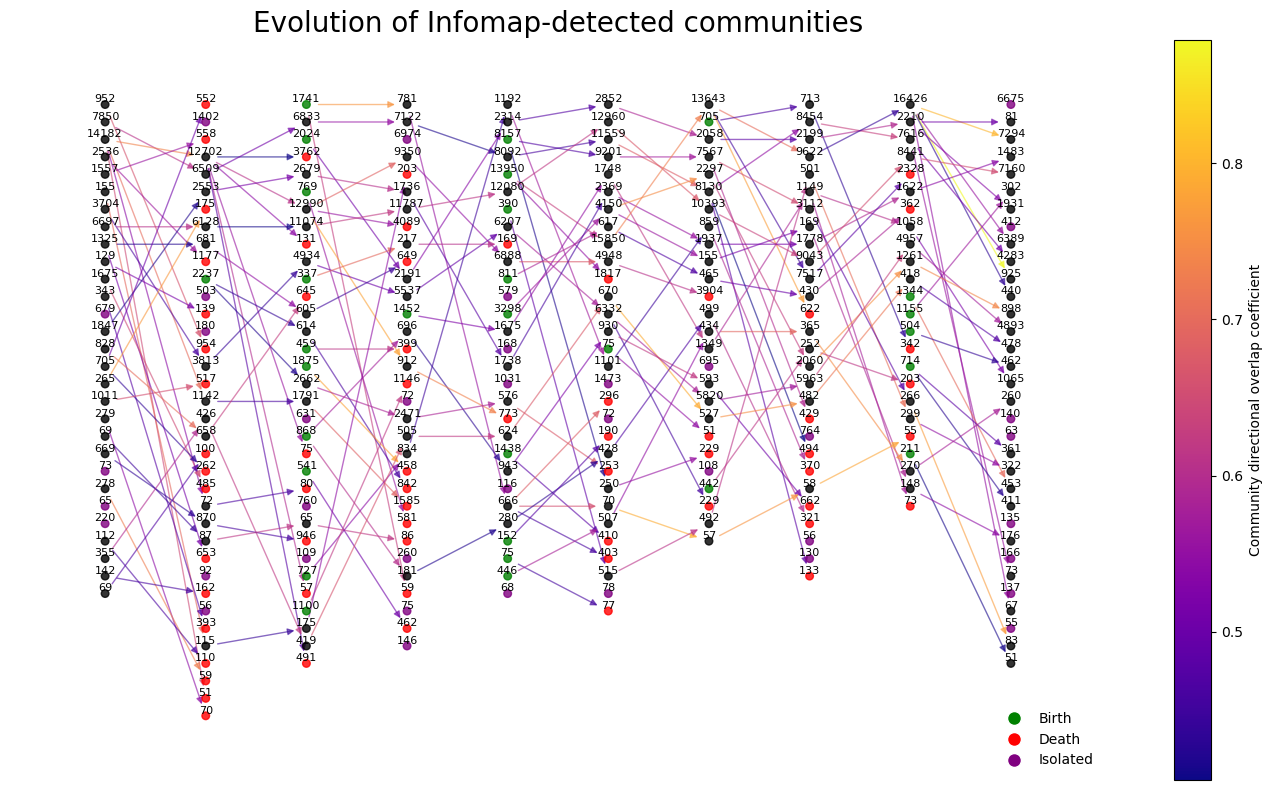

In [ ]:
plot_temporal_community_similarity(sim_matrices, community_sizes, node_size=30, clustering='Infomap', threshold=0.4)

#### Frequencies Entropy

In [ ]:
stats = []

for i in range(1, 8):
    print(f"Snapshot {i}")

    # load clustering
    file = os.path.join("infomap_clusterings", f"clust_snap{i}.json")
    with open(file, "r", encoding="utf-8") as f:
        part = json.load(f)

    # load graph
    file = os.path.join("networks_hybrid", f"graph_snap{i}_hybrid.igp")
    g = ig.Graph.Read_Pickle(file)

    # token -> frequency
    words_freqs = {v["token"]: v["freq"] for v in g.vs}

    snapshot_stats = []

    for com in part:
        freqs = [words_freqs[word] for word in com if word in words_freqs]
        s = community_freq_stats(freqs)

        if s is not None:
            snapshot_stats.append(s)

    stats.append(snapshot_stats)

Snapshot 1
Snapshot 2
Snapshot 3
Snapshot 4
Snapshot 5
Snapshot 6
Snapshot 7
Snapshot 8
Snapshot 9
Snapshot 10


In [ ]:
print_table(stats)

  Snapshot    Entropy (mean)    Entropy (median)    N_eff (mean)    N_eff (median)
----------  ----------------  ------------------  --------------  ----------------
         1             0.596               0.673          78.753             5.079
         2             0.615               0.683          88.029             7.486
         3             0.551               0.568          69.444             4.576
         4             0.599               0.645          78.154             3.724
         5             0.632               0.672         120.937             4.916
         6             0.623               0.660         140.590             9.085
         7             0.620               0.670         112.121             4.319
         8             0.644               0.680          98.565             4.917
         9             0.672               0.682         111.040             4.429
        10             0.613               0.635          72.782             4.740


##### Complexity Entropy

##### 0, 1, 2, 3

In [ ]:
stats = []

for i in range(1, 8):
    print(f"Snapshot {i}")

    # load clustering
    file = os.path.join("infomap_clusterings", f"clust_snap{i}.json")
    with open(file, "r", encoding="utf-8") as f:
        part = json.load(f)

    # load graph
    file = os.path.join("networks_hybrid", f"graph_snap{i}_hybrid.igp")
    g = ig.Graph.Read_Pickle(file)

    # token -> frequency
    words_freqs = {v["token"]: v["demauro_level"] for v in g.vs}

    snapshot_stats = []

    for com in part:
        freqs = [words_freqs[word] for word in com if word in words_freqs]
        s = demauro_entropy_stats(freqs)

        if s is not None:
            snapshot_stats.append(s)

    stats.append(snapshot_stats)

Snapshot 1
Snapshot 2
Snapshot 3
Snapshot 4
Snapshot 5
Snapshot 6
Snapshot 7
Snapshot 8
Snapshot 9
Snapshot 10


In [ ]:
print_table(stats)

  Snapshot    Entropy (mean)    Entropy (median)    N_eff (mean)    N_eff (median)
----------  ----------------  ------------------  --------------  ----------------
         1             0.439               0.445           1.626             1.629
         2             0.389               0.414           1.603             1.569
         3             0.339               0.360           1.476             1.454
         4             0.333               0.359           1.450             1.458
         5             0.284               0.303           1.380             1.451
         6             0.320               0.313           1.455             1.500
         7             0.365               0.391           1.503             1.559
         8             0.338               0.373           1.505             1.569
         9             0.346               0.409           1.571             1.665
        10             0.446               0.469           1.660             1.649


##### (0, 1, 2) vs 3

In [ ]:
stats = []

for i in range(1, 8):
    print(f"Snapshot {i}")

    # load clustering
    file = os.path.join("infomap_clusterings", f"clust_snap{i}.json")
    with open(file, "r", encoding="utf-8") as f:
        part = json.load(f)

    # load graph
    file = os.path.join("networks_hybrid", f"graph_snap{i}_hybrid.igp")
    g = ig.Graph.Read_Pickle(file)

    # token -> frequency
    words_freqs = {v["token"]:(1 if v["demauro_level"] == 3 else 0) for v in g.vs}

    snapshot_stats = []

    for com in part:
        freqs = [words_freqs[word] for word in com if word in words_freqs]
        s = demauro_entropy_stats(freqs)

        if s is not None:
            snapshot_stats.append(s)

    stats.append(snapshot_stats)

Snapshot 1
Snapshot 2
Snapshot 3
Snapshot 4
Snapshot 5
Snapshot 6
Snapshot 7
Snapshot 8
Snapshot 9
Snapshot 10


In [ ]:
print_table(stats)

  Snapshot    Entropy (mean)    Entropy (median)    N_eff (mean)    N_eff (median)
----------  ----------------  ------------------  --------------  ----------------
         1             0.530               0.592           1.470             1.507
         2             0.484               0.544           1.422             1.458
         3             0.420               0.500           1.365             1.414
         4             0.407               0.486           1.355             1.400
         5             0.355               0.447           1.305             1.364
         6             0.414               0.473           1.357             1.388
         7             0.450               0.521           1.394             1.435
         8             0.425               0.544           1.377             1.458
         9             0.452               0.589           1.403             1.504
        10             0.535               0.601           1.483             1.517


#### Cohesion and Connectivity

In [ ]:
import os
import igraph as ig
import json


stats = list()

for i in range(1, 8):
    print(f"Snapshot {i}")

    file = os.path.join("infomap_clusterings", f"clust_snap{i}.json")
    with open(file, "r", encoding="utf-8") as f:
        part = json.load(f)

    file = os.path.join("networks_hybrid", f"graph_snap{i}_hybrid.igp")
    g = ig.Graph.Read_Pickle(file)
    
    stats.append(list())
    
    for com in part:
        stats[-1].append(community_structure_stats(g, com))

Snapshot 1
Snapshot 2
Snapshot 3
Snapshot 4
Snapshot 5
Snapshot 6
Snapshot 7
Snapshot 8
Snapshot 9
Snapshot 10


In [ ]:
print_structural_snapshot_table(stats)


Snapshot | #Com | nNodes_mean | nNodes_med | nEdges_mean | nEdges_med | Conn_mean | Conn_med | Coh_mean | Coh_med | Coh_mean(w)
-------------------------------------------------------------------------------------------------------------------------------
       1 |   87 |       568.5 |       16.0 |       88851 |         70 |     0.563 |    0.571 |    0.666 |   0.661 |       0.589
       2 |   79 |       597.3 |       30.0 |       86841 |        206 |     0.480 |    0.410 |    0.657 |   0.650 |       0.590
       3 |  114 |       563.0 |       17.0 |      113576 |         88 |     0.558 |    0.564 |    0.672 |   0.668 |       0.591
       4 |  107 |       604.0 |       11.0 |      123616 |         34 |     0.595 |    0.667 |    0.678 |   0.672 |       0.589
       5 |   79 |       955.5 |       21.0 |      220718 |        110 |     0.546 |    0.527 |    0.681 |   0.668 |       0.591
       6 |   68 |      1218.0 |       36.0 |      317774 |        370 |     0.491 |    0.426 |    0.661

#### Community understanding

In [ ]:
centroids = list()

for i in range(1, 8):
    print(f"Snapshot {i}")

    file = os.path.join("infomap_clusterings", f"clust_snap{i}.json")
    with open(file, "r", encoding="utf-8") as f:
        part = json.load(f)

    file = os.path.join("networks_hybrid", f"graph_snap{i}_hybrid.igp")
    g = ig.Graph.Read_Pickle(file)
    
    centroids.append(list())
    
    for com in part:
        centroids[-1].append(topk_central_nodes_eigen(g, com))

Snapshot 1


/var/folders/68/gjrvx3m51494g9gp2r93j3vh0000gn/T/ipykernel_54644/592221401.py:12: RuntimeWarning: Some eigenvector centralities are nearly zero, indicating that the graph may not be (strongly) connected. Eigenvector centrality is not meaningful for disconnected graphs. Location: src/centrality/eigenvector.c:103
  eig = subg.eigenvector_centrality(


Snapshot 2
Snapshot 3
Snapshot 4
Snapshot 5
Snapshot 6
Snapshot 7
Snapshot 8
Snapshot 9
Snapshot 10


In [ ]:
centroids

[[[('giovedere', 1.0),
   ('martedì', 0.9955476785167899),
   ('lunedì', 0.9871251181520839)],
  [('sparpagliare', 1.0),
   ('attorcigliare', 0.9321014624265209),
   ('impalare', 0.9313384697223642)],
  [('estrinsecazione', 0.9999999999999999),
   ('semplicisticamenta', 0.9527472883358298),
   ('strumentalizzazione', 0.9045989943078596)],
  [('vejare', 1.0),
   ('endere', 0.9949477647473753),
   ('ciare', 0.9929044420297394)],
  [('nordafricano', 1.0),
   ('bombisto', 0.9954332200624041),
   ('indonesiana', 0.9756811666823441)],
  [('pontificare', 1.0),
   ('chiesa', 0.9920354430058886),
   ('episcopato', 0.9682349912605371)],
  [('newman', 0.9999999999999999),
   ('swing', 0.9420314499439404),
   ('laughton', 0.9415796242347922)],
  [('beccatello', 1.0),
   ('melchiorre', 0.991211100782087),
   ('spadaio', 0.9363147404331106)],
  [('polymer', 1.0),
   ('fornaciai', 0.9825043409424878),
   ('sacfem', 0.9751414686244333)],
  [('comunicai', 1.0),
   ('comunicare', 0.9993949848158096),
  

# RQ2 modularity and vdb bridge

In [3]:
import igraph as ig
import pickle
import numpy as np
import pandas as pd
from scipy.stats import entropy

# --- FASE 1: Identificazione del Core (token presenti in TUTTI i 7 snap) ---
all_sets = []
for i in range(1, 8):
    path = f'networks_hybrid_annotated/graph_snap{i}_hybrid.igp'
    with open(path, 'rb') as f:
        g_temp = pickle.load(f)
        # Usiamo l'attributo 'token' come identificativo unico
        all_sets.append(set(g_temp.vs['token']))

# Intersezione: otteniamo solo i token che "sopravvivono" per tutto il tempo
core_tokens = set.intersection(*all_sets)
print(f"Dimensioni del Core: {len(core_tokens)} nodi")

# --- FASE 2: Analisi del Core ---
results = []

for i in range(1, 8):
    path = f'networks_hybrid_annotated/graph_snap{i}_hybrid.igp'
    with open(path, 'rb') as f:
        g = pickle.load(f)
    
    # Selezioniamo solo i nodi che appartengono al core
    indices_to_keep = [v.index for v in g.vs if v['token'] in core_tokens]
    g_core = g.subgraph(indices_to_keep)
    
    # Rilevamento Comunità sul Core (Louvain pesato sulla cosine similarity)
    # Assumiamo che il peso sia nell'attributo 'weight' degli archi
    weights = g_core.es['weight'] if 'weight' in g_core.edge_attributes() else None
    clusters = g_core.community_multilevel(weights=weights)
    g_core.vs['community'] = clusters.membership
    
    # Calcolo VdB (demauro_level != 3) nel Core
    vdb_nodes = [v for v in g_core.vs if v['demauro_level'] != 3]
    total_vdb_core = len(vdb_nodes)
    
    vdb_distribution = []
    community_purity = []
    
    for c_id in range(len(clusters)):
        nodes_in_comm = [v for v in g_core.vs if v['community'] == c_id]
        size = len(nodes_in_comm)
        
        if size == 0: continue
        
        # Conteggio VdB nella comunità specifica
        vdb_in_comm = [v for v in nodes_in_comm if v['demauro_level'] != 3]
        count_vdb = len(vdb_in_comm)
        
        vdb_distribution.append(count_vdb)
        community_purity.append(count_vdb / size)

    # Entropia di Shannon normalizzata (dispersione del VdB)
    probs = [count / total_vdb_core for count in vdb_distribution if count > 0]
    H_norm = entropy(probs) / np.log(len(clusters)) if len(clusters) > 1 else 0
    
    results.append({
        'snapshot': i,
        'entropy_vdb': H_norm,
        'avg_purity': np.mean(community_purity),
        'num_communities': len(clusters),
        'modularity': g_core.modularity(clusters.membership)
    })

df_core_final = pd.DataFrame(results)
print(df_core_final)

Dimensioni del Core: 20113 nodi
   snapshot  entropy_vdb  avg_purity  num_communities  modularity
0         1     0.479442    0.385483               56    0.617048
1         2     0.583388    0.139118               36    0.593013
2         3     0.525819    0.157693               52    0.594524
3         4     0.574214    0.184335               39    0.569482
4         5     0.574509    0.157191               48    0.544043
5         6     0.539562    0.143196               62    0.575268
6         7     0.524793    0.180997               58    0.576608


In [5]:
import igraph as ig
import pickle
import numpy as np
import pandas as pd

bridge_results = []

for i in range(1, 8):
    path = f'networks_hybrid_annotated/graph_snap{i}_hybrid.igp'
    with open(path, 'rb') as f:
        g = pickle.load(f)
    
    # Isoliamo il Core
    indices_to_keep = [v.index for v in g.vs if v['token'] in core_tokens]
    g_core = g.subgraph(indices_to_keep)
    
    # Rilevamento comunità (stesso metodo dell'analisi modularità)
    clusters = g_core.community_multilevel(weights=g_core.es['weight'] if 'weight' in g_core.edge_attributes() else None)
    g_core.vs['community'] = clusters.membership
    
    inter_community_edges_count = 0
    vdb_bridge_count = 0
    
    for e in g_core.es:
        source, target = e.tuple
        # Se l'arco collega due comunità diverse
        if g_core.vs[source]['community'] != g_core.vs[target]['community']:
            inter_community_edges_count += 1
            # Controlliamo se almeno uno dei due nodi è VdB (demauro_level != 3)
            if g_core.vs[source]['demauro_level'] != 3 or g_core.vs[target]['demauro_level'] != 3:
                vdb_bridge_count += 1
                
    bridge_ratio = vdb_bridge_count / inter_community_edges_count if inter_community_edges_count > 0 else 0
    
    bridge_results.append({
        'snapshot': i,
        'vdb_bridge_ratio': bridge_ratio,
        'modularity': g_core.modularity(clusters.membership)
    })

df_bridge = pd.DataFrame(bridge_results)
print(df_bridge)

   snapshot  vdb_bridge_ratio  modularity
0         1          0.419893    0.614956
1         2          0.472179    0.594417
2         3          0.474970    0.597178
3         4          0.500949    0.570830
4         5          0.484692    0.548079
5         6          0.500346    0.570611
6         7          0.478201    0.575838


L'analisi del core rivela che l'impoverimento linguistico non si manifesta come scomparsa di termini, ma come un deterioramento della connettività specifica. L'aumento del vdb_bridge_ratio (fino al 50%) dimostra che il vocabolario di base ha assunto un ruolo centrale nella mediazione tra domini semantici diversi, causando una parallela erosione della modularità della rete. Il linguaggio è diventato strutturalmente più povero perché i confini tra i concetti sono diventati meno definiti e più dipendenti da un set ristretto di termini iper-frequenti."

In [4]:
import igraph as ig
import pickle
import numpy as np
import pandas as pd
import random

# --- FASE 1: DEFINIZIONE DEL CORE ---
# Dobbiamo trovare i token comuni a tutti i 7 snapshot prima di analizzarli
all_sets = []
print("Identificazione dei token nel Core...")
for i in range(1, 8):
    path = f'networks_hybrid_annotated/graph_snap{i}_hybrid.igp'
    with open(path, 'rb') as f:
        g_temp = pickle.load(f)
        all_sets.append(set(g_temp.vs['token']))

# Intersezione: prendiamo solo i nodi presenti ovunque
core_tokens = set.intersection(*all_sets)
print(f"Core identificato: {len(core_tokens)} nodi persistenti.")

# --- FASE 2: ANALISI CON NULL MODEL ---
bridge_results = []
N_PERMUTATIONS = 100 

for i in range(1, 8):
    path = f'networks_hybrid_annotated/graph_snap{i}_hybrid.igp'
    with open(path, 'rb') as f:
        g = pickle.load(f)
    
    # 1. Isoliamo il Core (ora core_tokens esiste!)
    indices_to_keep = [v.index for v in g.vs if v['token'] in core_tokens]
    g_core = g.subgraph(indices_to_keep)
    
    # 2. Rilevamento comunità
    # Usiamo il peso (cosine similarity) se disponibile
    weights = g_core.es['weight'] if 'weight' in g_core.edge_attributes() else None
    clusters = g_core.community_multilevel(weights=weights)
    g_core.vs['community'] = clusters.membership
    
    # 3. Calcolo Bridge Ratio REALE
    inter_community_edges = [e for e in g_core.es if g_core.vs[e.source]['community'] != g_core.vs[e.target]['community']]
    total_inter = len(inter_community_edges)
    
    # Calcolo VdB reale (demauro_level != 3)
    vdb_bridge_count = sum(1 for e in inter_community_edges if g_core.vs[e.source]['demauro_level'] != 3 
                           or g_core.vs[e.target]['demauro_level'] != 3)
    
    real_ratio = vdb_bridge_count / total_inter if total_inter > 0 else 0
    
    # 4. NULL MODEL: Shuffling delle etichette De Mauro
    labels_pool = [v['demauro_level'] for v in g_core.vs]
    null_ratios = []
    
    for _ in range(N_PERMUTATIONS):
        shuffled_labels = random.sample(labels_pool, len(labels_pool))
        null_vdb_count = 0
        for e in inter_community_edges:
            if shuffled_labels[e.source] != 3 or shuffled_labels[e.target] != 3:
                null_vdb_count += 1
        null_ratios.append(null_vdb_count / total_inter if total_inter > 0 else 0)
    
    # 5. Statistiche e Z-Score
    mean_null = np.mean(null_ratios)
    std_null = np.std(null_ratios)
    z_score = (real_ratio - mean_null) / std_null if std_null > 0 else 0
    
    bridge_results.append({
        'snapshot': i,
        'vdb_bridge_ratio': real_ratio,
        'null_mean': mean_null,
        'null_std': std_null,
        'z_score': z_score,
        'modularity': g_core.modularity(clusters.membership)
    })
    print(f"Snap {i}: Real {real_ratio:.3f} | Null {mean_null:.3f} | Z-Score {z_score:.2f}")

df_bridge_null = pd.DataFrame(bridge_results)
print("\n--- RISULTATI FINALI ---")
print(df_bridge_null)

Identificazione dei token nel Core...
Core identificato: 20113 nodi persistenti.
Snap 1: Real 0.409 | Null 0.492 | Z-Score -13.34
Snap 2: Real 0.476 | Null 0.493 | Z-Score -2.53
Snap 3: Real 0.488 | Null 0.491 | Z-Score -0.48
Snap 4: Real 0.504 | Null 0.492 | Z-Score 2.13
Snap 5: Real 0.500 | Null 0.492 | Z-Score 1.31
Snap 6: Real 0.493 | Null 0.493 | Z-Score 0.05
Snap 7: Real 0.480 | Null 0.493 | Z-Score -2.47

--- RISULTATI FINALI ---
   snapshot  vdb_bridge_ratio  null_mean  null_std    z_score  modularity
0         1          0.409113   0.492021  0.006215 -13.340139    0.614063
1         2          0.475765   0.492538  0.006630  -2.529733    0.592046
2         3          0.488477   0.491186  0.005593  -0.484501    0.598005
3         4          0.504467   0.492162  0.005768   2.133398    0.564200
4         5          0.499845   0.492475  0.005646   1.305454    0.555670
5         6          0.492963   0.492721  0.004780   0.050669    0.573913
6         7          0.480138   0.493135 